EN ESTE NOTEBOOK:
- Se hace un cambio en df1 ('eg_deter_sflt1_pglf' = 39.3 en ID = 487). Lo arreglamos en reunion6.ipybn.
- Se crea df2 ('datos_embarazo_imp3.csv') con las variables numéricas y categóricas, sin categorizar los biomarcadores, para proceder a la imputación.
- En df2 se reemplazan 'ratio', 'slft', 'plgf' por las mismas variables transformadas.
- Se hace clústering de K-Means con k = 2, ..., 10 incluyendo las variables numéricas de df2 excepto 'eg_deter_sflt1_plgf' ni 'eg_eco_1tri'. Para esto hay que aplicar StandardScaler antes. Además, se evalúan las tres métricas (Silhouette Score, Calinski-Harabasz y Davies-Bouldin). También se hace una descripción del clústering para el mejor valor de k en función de las variables numéricas de entrada. Luego, también se analiza el clústering en función de las variables de ecocargadiografía y TA pasados unos años (para ver si vemos relación en los grupos que nos salgan con esas variables)

In [2]:
import pandas as pd
import numpy as np

**Partimos de 'datos_embarazo.csv'**

In [3]:
df2 = pd.read_csv('datos_embarazo.csv')

In [4]:
# Modificar el ID 15: fecha_eco_1tri y eg_eco_1tri
df2.loc[df2['id'] == 15, ['fecha_eco_1tri', 'eg_eco_1tri']] = ['2020-02-13', 12.3]

df2.loc[df2['id'] == 487, ['eg_deter_sflt1_plgf', 'fecha_ult_deter']] = [39.3, '2021-02-18']

# Modificar el ID 55: fecha_parto y eg_parto
df2.loc[df2['id'] == 55, ['fecha_parto', 'eg_parto']] = ['2019-02-07', 37.6]

# Modificar el ID 383: fecha_parto y eg_parto
df2.loc[df2['id'] == 383, ['fecha_parto', 'eg_parto']] = ['2020-07-19', 39.0]

# Modificar el ID 585: fecha_parto y eg_parto
df2.loc[df2['id'] == 585, ['fecha_parto', 'eg_parto']] = ['2019-09-03', 40.5]

# Eliminar las pacientes con ID 392, 568 y 647
ids_a_eliminar = [392, 568, 647]
df2 = df2[~df2['id'].isin(ids_a_eliminar)]

In [5]:
# Eliminar las variables de fechas y determinaciones
columnas_a_eliminar = [
    'fecha_firma_ci_cardiomom', 
    'fecha_firma_ci_muestbio', 
    'fecha_nac', 
    'fur_pre', 
    'fecha_eco_1tri', 
    'fecha_ult_deter', 
    'fecha_parto',
    'uterinas_p95_1tri', 
    'plgf_1tri', 
    'uterinas_p95_eco_2tri', 
    'deter_sflt1_plgf_gest',
    'Unnamed: 0'
]

# Eliminar las columnas del DataFrame
df2 = df2.drop(columns=columnas_a_eliminar, errors='ignore')

# Opcional: Verificar las columnas restantes
print("Columnas actuales en el DataFrame:")
print(df2.columns.tolist())

Columnas actuales en el DataFrame:
['id', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'nivel_estudios', 'parto_previo_mayor37_pre', 'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg', 'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 'enf_autoinm', 'fuma', 'alcohol', 'drogas', 'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'eg_eco_1tri', 'riesgo_pe_1tri', 'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'ratio_sflt1_plgf', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'histerectomia', 'otras', 'hipertension_gest', 'pe', 'sd_hellp', 'desprendimiento_placenta', 'obito_fetal', 'hemocerebral_ictus', 'embolia_tep', 'trombosis_venosa_prof', 'uci_materna_ucoi', 'covid', 'cir', 'peg', 'diabetes_gest', 'colestasis_intrahepatica', 'corioamnionitis', 'estudio_inicial_Angioco

In [6]:
df2.shape

(456, 79)

# Imputación con Miss Forest

In [ ]:
# COMPROBACIÓN DE QUE TODAS LAS VARIABLES SON NUMÉRICAS

vars_numericas = df2.select_dtypes(include=['number']).columns.tolist()

tabla_numericas = pd.DataFrame(vars_numericas, columns=['Variables Numéricas'])

print("TABLA DE NUMÉRICAS")
print(tabla_numericas)

TABLA DE NUMÉRICAS
      Variables Numéricas
0                      id
1           peso_ini_gest
2           peso_fin_gest
3       aumento_peso_gest
4                   talla
..                    ...
74      sexo_rn_Masculino
75          tomo_Aspirina
76          tomo_Heparina
77  tomo_Antihipertensivo
78           tomo_Ninguna

[79 rows x 1 columns]


In [8]:
numericas = ['id', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 
            'eg_parto', 'valor_sflt1', 'eg_deter_sflt1_plgf', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'eg_eco_1tri', 'valor_plgf', 'ratio_sflt1_plgf']

In [9]:
ordinales = ['nivel_estudios', 'riesgo_pe_1tri']

In [10]:
# Import basics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

## Imputación con MissForest para las numéricas y las categóricas ordinales

In [11]:
# Para asegurar que el imputador funcione bien convertimos los valores faltantes, representados en blanco, a NaN
df2.replace("", np.nan, inplace=True)

In [12]:
min_values_dict = df2.min().to_dict()
max_values_dict = df2.max().to_dict()

In [13]:
min_values_dict

{'id': 1.0,
 'peso_ini_gest': 42.0,
 'peso_fin_gest': 46.0,
 'aumento_peso_gest': -5.0,
 'talla': 144.0,
 'imc_ini_gest': 17.04,
 'nivel_estudios': 1.0,
 'parto_previo_mayor37_pre': 0.0,
 'parto_previo_menor37_pre': 0.0,
 'aborto_menor20': 0.0,
 'ant_cir': 0.0,
 'ant_peg': 0.0,
 'ant_obito': 0.0,
 'ant_pe': 0.0,
 'ant_hellp': 0.0,
 'ant_cesarea': 0.0,
 'ant_diabetes_pregest': 0.0,
 'hta_pregest': 0.0,
 'sindr_antifosfolipido': 0.0,
 'enf_autoinm': 0.0,
 'fuma': 0.0,
 'alcohol': 0.0,
 'drogas': 0.0,
 'edad_materna_gest': 17.18,
 'tas_1tri': 82.0,
 'tad_1tri': 39.0,
 'eg_eco_1tri': 9.3,
 'riesgo_pe_1tri': 0.0,
 'eg_deter_sflt1_plgf': 11.6,
 'valor_sflt1': 84.0,
 'valor_plgf': 12.0,
 'ratio_sflt1_plgf': 0.191407574901074,
 'eg_parto': 26.8,
 'ini_trabajo_parto_espontaneo': 0.0,
 'peso_rn': 820.0,
 'apgar_1min': 1.0,
 'apgar_5min': 1.0,
 'apgar_10min': 8.0,
 'hemorragia_pospart_transfusion': 0.0,
 'edema_agudo_pulmon': 0.0,
 'histerectomia': 0.0,
 'otras': 0.0,
 'hipertension_gest': 0.0,
 

In [14]:
# Definimos cada variable según su tipo
df_num = df2[numericas]
df_cat_ord = df2[ordinales]

In [15]:
# Probar esto para ver que los min/max son correctos
min_values_num = [min_values_dict[col] for col in df_num.columns]
max_values_num = [max_values_dict[col] for col in df_num.columns]
min_values_num

[1.0,
 42.0,
 46.0,
 -5.0,
 144.0,
 17.04,
 820.0,
 1.0,
 1.0,
 8.0,
 26.8,
 84.0,
 11.6,
 82.0,
 39.0,
 17.18,
 9.3,
 12.0,
 0.191407574901074]

In [16]:
min_values_all = [min_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
max_values_all = [max_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
max_values_all

[660.0,
 142.0,
 148.0,
 38.7,
 185.0,
 53.42,
 4640.0,
 10.0,
 10.0,
 10.0,
 42.9,
 40098.0,
 41.6,
 165.0,
 109.0,
 47.1,
 14.9,
 3688.0,
 1112.59711431742,
 3.0,
 1.0]

In [17]:
# Utilizamos el código para imputar sin hacer división train/test
# Funciones para la imputación
def _missForest_fit(data, num_estimators, m_depth, m_samples_leaf, max_iter,
                    min_value=None, max_value=None, random_state=1234):
    tree = ExtraTreesRegressor(
        n_estimators=num_estimators,
        random_state=random_state,
        max_depth=m_depth,
        min_samples_leaf=m_samples_leaf
    )
    imputer = IterativeImputer(
        estimator=tree,
        random_state=random_state,
        max_iter=max_iter,
        min_value=min_value,
        max_value=max_value,
        imputation_order='ascending',
        initial_strategy='mean',
        verbose=2
    )
    imputer.fit(data)
    return imputer

def _missForest_transform(imputer, data):
    return imputer.transform(data)


def imputacion_pipeline_all(data_num, data_cat,
                            num_estimators, m_depth, m_samples_leaf,
                            max_iter, random_state=1234,
                            guardar_imputador=True):

    # Obtener min/max automáticamente por nombre de variable
    min_values_num = [min_values_dict[col] for col in data_num.columns]
    max_values_num = [max_values_dict[col] for col in data_num.columns]

    min_values_all = [min_values_dict[col] for col in list(data_num.columns) + list(data_cat.columns)]
    max_values_all = [max_values_dict[col] for col in list(data_num.columns) + list(data_cat.columns)]

    # Imputación de numéricas
    imputer_num = _missForest_fit(
        data_num, num_estimators, m_depth, m_samples_leaf,
        max_iter, min_value=min_values_num,
        max_value=max_values_num,
        random_state=random_state
    )

    data_num_imp = pd.DataFrame(
        _missForest_transform(imputer_num, data_num),
        columns=data_num.columns,
        index=data_num.index
    )

    # Unir con categóricas (ordinales)
    data_all = pd.concat([data_num_imp, data_cat], axis=1)

    # Imputación conjunta
    imputer_all = _missForest_fit(
        data_all, num_estimators, m_depth, m_samples_leaf,
        max_iter, min_value=min_values_all,
        max_value=max_values_all,
        random_state=random_state
    )

    data_all_imp = _missForest_transform(imputer_all, data_all)

    # Control de variables categóricas (ordinales)
    for i in range(data_num.shape[1], data_all.shape[1]):
        data_all_imp[:, i] = np.clip(data_all_imp[:, i], min_values_all[i], max_values_all[i])

    data_final = pd.DataFrame(data_all_imp, columns=data_all.columns, index=data_all.index)

    for col in data_cat.columns:
        data_final[col] = data_final[col].round().astype(int)

    if guardar_imputador:
        joblib.dump(imputer_all, 'imputador_missforest.pkl')
        print("Imputador guardado como 'imputador_missforest.pkl'")

    return data_final

In [18]:
data_final = imputacion_pipeline_all(
    data_num=df_num,
    data_cat=df_cat_ord,   # aquí SOLO ordinales (codificadas como enteros)
    num_estimators=50,
    m_depth=4,
    m_samples_leaf=3,
    max_iter=100,
    random_state=1234,
    guardar_imputador=True)

[IterativeImputer] Completing matrix with shape (456, 19)
[IterativeImputer] Ending imputation round 1/100, elapsed time 0.55
[IterativeImputer] Change: 3286.8991098508163, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 2/100, elapsed time 1.11
[IterativeImputer] Change: 4262.484660688201, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 3/100, elapsed time 1.65
[IterativeImputer] Change: 1306.584225443186, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 4/100, elapsed time 2.19
[IterativeImputer] Change: 950.0220722145806, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 5/100, elapsed time 2.74
[IterativeImputer] Change: 726.8791878344988, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 6/100, elapsed time 3.31
[IterativeImputer] Change: 503.7297507390658, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 7/100, elapsed time 3.87
[IterativeImputer] Change: 526.89

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 10/100, elapsed time 0.22
[IterativeImputer] Ending imputation round 11/100, elapsed time 0.24
[IterativeImputer] Ending imputation round 12/100, elapsed time 0.26
[IterativeImputer] Ending imputation round 13/100, elapsed time 0.28
[IterativeImputer] Ending imputation round 14/100, elapsed time 0.31
[IterativeImputer] Ending imputation round 15/100, elapsed time 0.33
[IterativeImputer] Ending imputation round 16/100, elapsed time 0.35
[IterativeImputer] Ending imputation round 17/100, elapsed time 0.37
[IterativeImputer] Ending imputation round 18/100, elapsed time 0.39
[IterativeImputer] Ending imputation round 19/100, elapsed time 0.42
[IterativeImputer] Ending imputation round 20/100, elapsed time 0.44
[IterativeImputer] Ending imputation round 21/100, elapsed time 0.46
[IterativeImputer] Ending imputation round 22/100, elapsed time 0.48
[IterativeImputer] Ending imputation round 23/100, elapsed time 0.51
[IterativeImputer] Ending imputati

## Imputación con SimplerImputer para las categóricas nominales

In [19]:
nominales_post_onehot = ['corioamnionitis', 'colestasis_intrahepatica', 
                'diabetes_gest', 'peg', 'cir', 'covid', 'uci_materna_ucoi', 'obito_fetal', 'desprendimiento_placenta', 'sd_hellp', 
                'pe', 'hipertension_gest', 'otras', 'histerectomia', 'edema_agudo_pulmon', 'hemorragia_pospart_transfusion', 
                'ini_trabajo_parto_espontaneo', 'alcohol', 
                'drogas', 'fuma', 'sindr_antifosfolipido', 'enf_autoinm', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'ant_peg', 
                'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cir', 'aborto_menor20', 'parto_previo_mayor37_pre', 'parto_previo_menor37_pre',
                'hemocerebral_ictus', 'trombosis_venosa_prof', 'embolia_tep',
                'estudio_inicial_Angiocor', 'estudio_inicial_BiSC', 'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno', 
                'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto', 'etnia_Negra', 'etnia_Sureste_asiatico', 
                'concepcion_Espontanea', 'concepcion_FIV', 'concepcion_FIV_ovodonacion', 'concepcion_Inseminacion', 
                'tipo_parto_Cesarea', 'tipo_parto_Eutocico', 'tipo_parto_Instrumentado', 
                'sexo_rn_Masculino',
                'tomo_Aspirina', 'tomo_Heparina', 'tomo_Antihipertensivo', 'tomo_Ninguna']

                
df_cat_nom = df2[nominales_post_onehot]

In [20]:
def impute_nominal_simple(X_nom):
    imp = SimpleImputer(strategy='most_frequent')
    X_nom_imp = pd.DataFrame(imp.fit_transform(X_nom), columns=X_nom.columns, index=X_nom.index)
    return X_nom_imp, imp

In [21]:
X_nom_imp, imp = impute_nominal_simple(df_cat_nom)

## Unión de todas las variables imputadas

In [22]:
df_imp = pd.concat([data_final, X_nom_imp], axis=1)

In [23]:
# Comprobar que no hay valores faltantes
df_imp.isna().sum().sum()

np.int64(0)

In [24]:
df_imp

,id,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,valor_sflt1,eg_deter_sflt1_plgf,tas_1tri,tad_1tri,edad_materna_gest,eg_eco_1tri,valor_plgf,ratio_sflt1_plgf,nivel_estudios,riesgo_pe_1tri,corioamnionitis,colestasis_intrahepatica,diabetes_gest,peg,cir,covid,uci_materna_ucoi,obito_fetal,desprendimiento_placenta,sd_hellp,pe,hipertension_gest,otras,histerectomia,edema_agudo_pulmon,hemorragia_pospart_transfusion,ini_trabajo_parto_espontaneo,alcohol,drogas,fuma,sindr_antifosfolipido,enf_autoinm,ant_cesarea,ant_diabetes_pregest,hta_pregest,ant_peg,ant_obito,ant_pe,ant_hellp,ant_cir,aborto_menor20,parto_previo_mayor37_pre,parto_previo_menor37_pre,hemocerebral_ictus,trombosis_venosa_prof,embolia_tep,estudio_inicial_Angiocor,estudio_inicial_BiSC,estudio_inicial_EUROPE,estudio_inicial_Ninguno,etnia_Asia_Oriental,etnia_Blanca,etnia_Latina,etnia_Mixto,etnia_Negra,etnia_Sureste_asiatico,concepcion_Espontanea,concepcion_FIV,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna
0,1.0,57.6,68.000000,10.400000,166.0,20.90,1970.0,8.0,9.0,10.0,34.9,11690.0,35.0,113.304681,73.965763,33.08,12.300000,46.0,254.130435,2,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,2.0,54.0,60.000000,6.000000,163.0,20.32,1980.0,9.0,10.0,10.0,37.3,9809.0,37.2,111.799415,72.667189,42.81,13.200000,47.0,208.702128,3,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,4.0,71.0,82.000000,11.000000,157.0,28.80,1380.0,6.0,8.0,9.0,33.8,9061.0,33.0,118.447342,78.755516,38.36,12.500000,12.0,755.083333,2,1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,5.0,46.0,50.400000,4.400000,156.0,18.90,2950.0,9.0,10.0,10.0,39.0,1794.0,32.8,108.000000,65.000000,30.72,11.500000,605.3,2.963820,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,8.0,55.8,70.000000,14.200000,157.0,22.64,3350.0,9.0,10.0,10.0,40.6,2247.0,40.5,113.000000,80.000000,32.56,12.600000,219.0,10.260274,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,656.0,58.2,76.500000,18.300000,161.0,22.45,3510.0,9.0,10.0,10.0,39.2,3615.0,31.8,97.000000,70.000000,33.34,12.800000,547.9,6.597919,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
455,657.0,57.9,74.500000,16.600000,163.0,21.79,3020.0,8.0,10.0,10.0,36.8,12728.0,36.8,102.000000,64.000000,30.99,12.900000,191.0,66.638743,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0

# Reemplazar variables

Se reemplazan las siguientes variables en df_imp:
- 'ratio_sflt1_plgf' por 'ratio_MoM'
- 'valor_sflt1' por 'sflt1_MoM'
- 'valor_plgf' por 'valor_MoM'

de la siguiente manera:
- cada valor de 'ratio_sflt1_plgf' se divide entre 24.8 si 'eg_deter_sflt1_plgf' está entre 10 y 14, se divide entre 10.5 si 'eg_deter_sflt1_plgf' está entre 15 y 19, se divide entre 4.92 si 'eg_deter_sflt1_plgf' está entre 20 y 23, se divide entre 3.06 si 'eg_deter_sflt1_plgf' está entre 24 y 28, se divide entre 3.75 si 'eg_deter_sflt1_plgf' está entre 29 y 33, se divide entre 9.03 si 'eg_deter_sflt1_plgf' está entre 34 y 36 y se divide entre 19.6 si 'eg_deter_sflt1_plgf' es mayor o igual a 37. Los resultados obtenidos se almacenan en una nueva columna llamada 'ratio_MoM'

- cada valor de 'valor_sflt1' se divide entre 1328 si 'eg_deter_sflt1_plgf' está entre 10 y 14, se divide entre 1355 si 'eg_deter_sflt1_plgf' está entre 15 y 19, se divide entre 1299 si 'eg_deter_sflt1_plgf' está entre 20 y 23, se divide entre 1355 si 'eg_deter_sflt1_plgf' está entre 24 y 28, se divide entre 1742 si 'eg_deter_sflt1_plgf' está entre 29 y 33, se divide entre 2552 si 'eg_deter_sflt1_plgf' está entre 34 y 36 y se divide entre 3485 si 'eg_deter_sflt1_plgf' es mayor o igual a 37. Los resultados obtenidos se almacenan en una nueva columna llamada 'sflt1_MoM'

- cada valor de 'valor_plgf' se divide entre 52.6 si 'eg_deter_sflt1_plgf' está entre 10 y 14, se divide entre 135 si 'eg_deter_sflt1_plgf' está entre 15 y 19, se divide entre 264 si 'eg_deter_sflt1_plgf' está entre 20 y 23, se divide entre 465 si 'eg_deter_sflt1_plgf' está entre 24 y 28, se divide entre 471 si 'eg_deter_sflt1_plgf' está entre 29 y 33, se divide entre 284 si 'eg_deter_sflt1_plgf' está entre 34 y 36 y se divide entre 191 si 'eg_deter_sflt1_plgf' es mayor o igual a 37. Los resultados obtenidos se almacenan en una nueva columna llamada 'plgf_MoM'

In [25]:
def calcular_mom_variables(df):
    # Definimos las condiciones basadas en 'eg_deter_sflt1_plgf'
    condiciones = [
        (df['eg_deter_sflt1_plgf'] >= 10) & (df['eg_deter_sflt1_plgf'] < 15), # 10 a 14.99
        (df['eg_deter_sflt1_plgf'] >= 15) & (df['eg_deter_sflt1_plgf'] < 20), # 15 a 19.99
        (df['eg_deter_sflt1_plgf'] >= 20) & (df['eg_deter_sflt1_plgf'] < 24),
        (df['eg_deter_sflt1_plgf'] >= 24) & (df['eg_deter_sflt1_plgf'] < 29),
        (df['eg_deter_sflt1_plgf'] >= 29) & (df['eg_deter_sflt1_plgf'] < 34),
        (df['eg_deter_sflt1_plgf'] >= 34) & (df['eg_deter_sflt1_plgf'] < 37),
        (df['eg_deter_sflt1_plgf'] >= 37)
]

    # Divisores para cada columna
    div_ratio = [24.8, 10.5, 4.92, 3.06, 3.75, 9.03, 19.6]
    div_sflt1 = [1328, 1355, 1299, 1355, 1742, 2552, 3485]
    div_plgf  = [52.6, 135, 264, 465, 471, 284, 191]

    # Aplicamos np.select para obtener el divisor correspondiente a cada fila
    # Si no cumple ninguna condición, devuelve NaN (np.nan)
    df['ratio_MoM'] = df['ratio_sflt1_plgf'] / np.select(condiciones, div_ratio, default=np.nan)
    df['sflt1_MoM'] = df['valor_sflt1'] / np.select(condiciones, div_sflt1, default=np.nan)
    df['plgf_MoM']  = df['valor_plgf'] / np.select(condiciones, div_plgf, default=np.nan)

    return df

In [26]:
df_imp = calcular_mom_variables(df_imp)

In [27]:
df_imp[['ratio_sflt1_plgf', 'eg_deter_sflt1_plgf']]

,ratio_sflt1_plgf,eg_deter_sflt1_plgf
0,254.130435,35.0
1,208.702128,37.2
2,755.083333,33.0
3,2.963820,32.8
4,10.260274,40.5
...,...,...
454,6.597919,31.8
455,66.638743,36.8
456,2.524777,36.9
457,4.898021,32.9


In [28]:
df_imp['ratio_MoM']

0       28.142905
1       10.648068
2      201.355556
3        0.790352
4        0.523483
          ...    
454      1.759445
455      7.379706
456      0.279599
457      1.306139
458      1.713784
Name: ratio_MoM, Length: 456, dtype: float64

In [29]:
variables_a_borrar = ['ratio_sflt1_plgf', 'valor_sflt1', 'valor_plgf']
df_imp = df_imp.drop(columns=variables_a_borrar, errors='ignore')

In [30]:
df_imp.to_csv('datos_embarazo_imp3.csv')

# Clústering con K-Means

In [31]:
# Seleccionar variables numéricas para el clustering
numericas_cols = ['id', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 
                  'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'eg_parto', 'sflt1_MoM', 
                  'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'plgf_MoM', 'ratio_MoM']

# Dejamos la columna 'id' fuera del escalado
features_clustering = [col for col in numericas_cols if col != 'id']

df_cluster = df_imp[numericas_cols].copy()

# Tratamiento de posibles valores que no han podido ser calculados (p. ej. si MoM devolvió NaN)
df_cluster = df_cluster.dropna()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features_clustering])

# Convertir el resultado a dataframe
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering, index=df_cluster.index)
df_scaled.head()

,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,sflt1_MoM,tas_1tri,tad_1tri,edad_materna_gest,plgf_MoM,ratio_MoM
0,-0.641023,-0.700718,-0.239293,0.360959,-0.778840,-1.749690,-0.727130,-1.049868,0.274160,-1.880121,1.415512,-0.091797,0.104653,-0.523729,-1.042971,0.665625
1,-0.888831,-1.228348,-1.041577,-0.129943,-0.891232,-1.733718,0.244686,0.307242,0.274160,-0.785197,0.528982,-0.221917,-0.051281,1.555515,-0.966970,0.105180
2,0.281376,0.222634,-0.129890,-1.111749,0.752009,-2.692042,-2.670762,-2.406977,-2.707871,-2.381961,1.727123,0.352752,0.679811,0.604576,-1.166319,6.214478
3,-1.439517,-1.861504,-1.333317,-1.275383,-1.166397,-0.184428,0.244686,0.307242,0.274160,-0.009625,-0.366932,-0.550351,-0.971965,-1.028047,-0.027982,-0.210611
4,-0.764927,-0.568810,0.453590,-1.111749,-0.441666,0.454455,0.244686,0.307242,0.274160,0.720325,-0.560236,-0.118134,0.829250,-0.634850,-0.153180,-0.219160


In [32]:
# Aplicamos K-Means para distintos valores de k y calculamos métricas
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

k_values = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_scores = []

# Fijamos random_state por reproducibilidad
random_state = 1234

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(df_scaled, labels))
    davies_scores.append(davies_bouldin_score(df_scaled, labels))

# Mostramos los resultados en un DataFrame
metrics_df = pd.DataFrame({
    'k': k_values,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_scores
})

metrics_df

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.514153,101.380994,1.335094
1,3,0.205525,96.641848,1.661596
2,4,0.214841,82.185134,1.542462
3,5,0.122749,75.483652,1.818842
4,6,0.112417,68.829583,1.815603
5,7,0.118091,65.119275,1.559501
6,8,0.099799,60.673364,1.725043
7,9,0.099610,55.457272,1.775666
8,10,0.098098,53.564583,1.650638


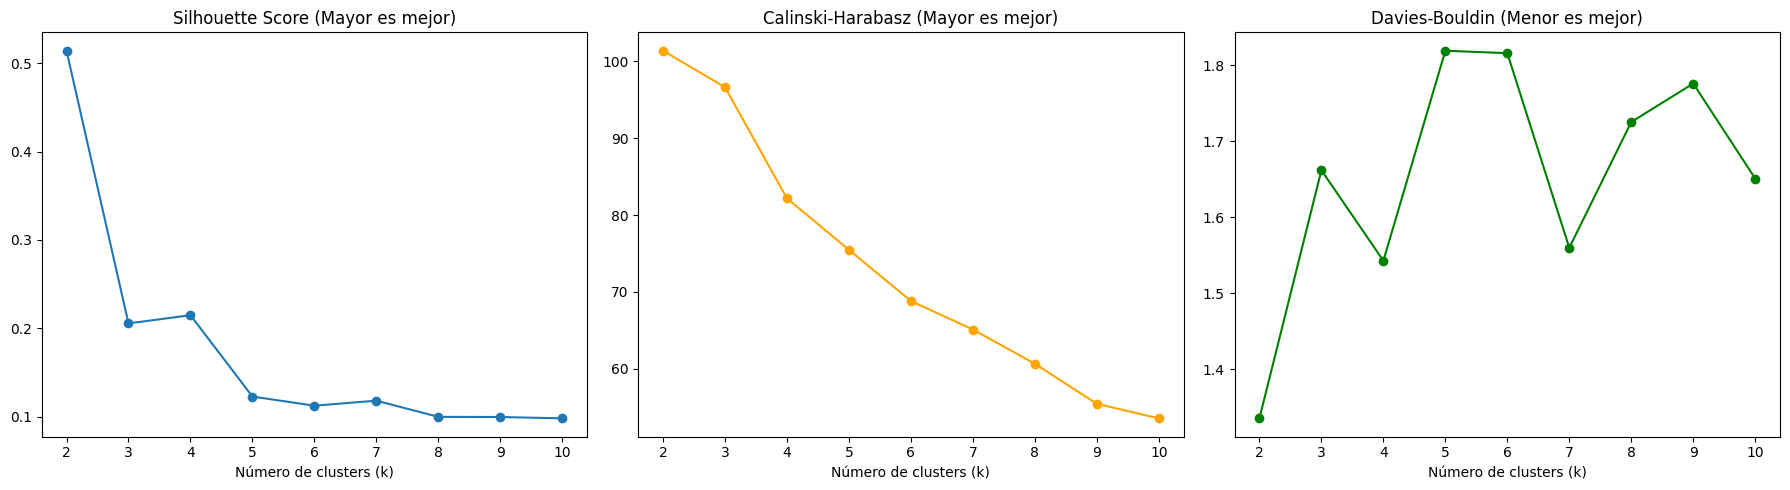

In [33]:
# Gráficas de las métricas
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score (Mayor es mejor)')
plt.xlabel('Número de clusters (k)')

plt.subplot(1, 3, 2)
plt.plot(k_values, calinski_scores, marker='o', color='orange')
plt.title('Calinski-Harabasz (Mayor es mejor)')
plt.xlabel('Número de clusters (k)')

plt.subplot(1, 3, 3)
plt.plot(k_values, davies_scores, marker='o', color='green')
plt.title('Davies-Bouldin (Menor es mejor)')
plt.xlabel('Número de clusters (k)')

plt.tight_layout()
plt.show()

In [34]:
# Determinación del mejor k
# El mejor k suele ser el que maximiza Silhouette y Calinski, y minimiza Davies.
best_k = metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'k']
print(f"El mejor k basado en el Silhouette Score es: {best_k}")

# Aplicar KMeans con el mejor k
kmeans_best = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
df_cluster['Cluster'] = kmeans_best.fit_predict(df_scaled)

# Añadimos el cluster al df_imp original 
df_imp_clustered = df_imp.copy()
df_imp_clustered['Cluster'] = df_cluster['Cluster'] 

El mejor k basado en el Silhouette Score es: 2


## Descripción del clústeringcclúster para k = 2

In [35]:
# Descripción de los clústeres usando las variables de entrada numéricas
cluster_summary = df_cluster.groupby('Cluster').mean()
cluster_summary

,id,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,sflt1_MoM,tas_1tri,tad_1tri,edad_materna_gest,plgf_MoM,ratio_MoM
Cluster,,,,,,,,,,,,,,,,,
0,340.448276,72.538023,84.115660,11.571023,161.672414,27.767585,1956.275862,5.848968,7.80302,8.964538,34.134483,6.054825,121.019075,79.862252,37.794828,0.730450,77.379839
1,367.004684,66.530284,78.251442,11.721960,163.938204,24.725783,3140.800629,8.945123,9.90744,9.972143,39.352975,1.469200,113.914801,72.634591,35.377073,1.355878,2.609664


/var/folders/h2/lk1h3scx0p3cs7sk_k_sxylh0000gn/T/ipykernel_13768/2284002198.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


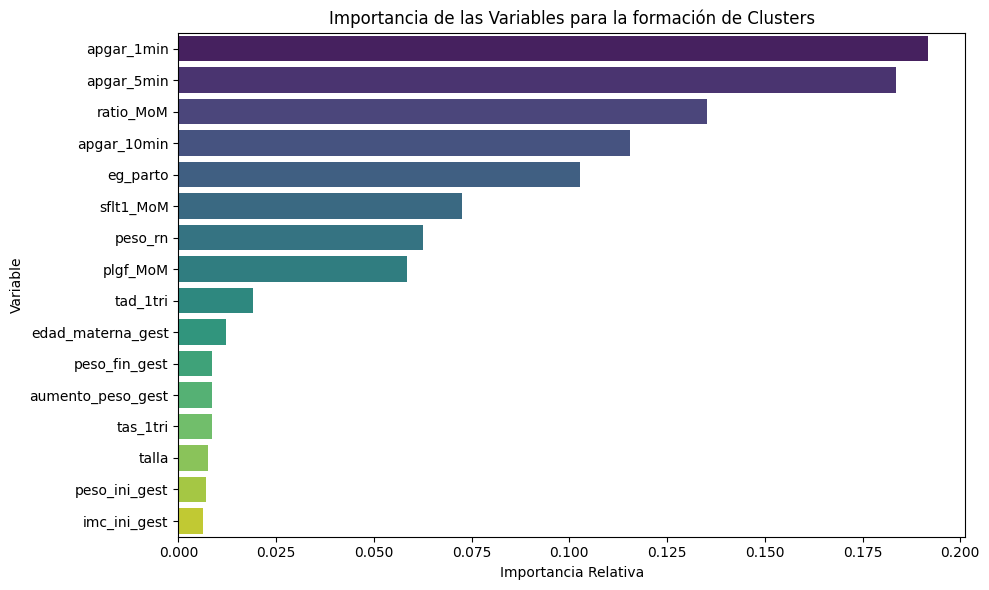

In [36]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos (X son las variables, y es el cluster)
X = df_scaled 
y = df_cluster['Cluster']

# Definir y entrenar el modelo
rf = RandomForestClassifier(n_estimators=100, random_state=1234)
rf.fit(X, y)

# Extraer la importancia de las variables
importances = rf.feature_importances_
feature_names = X.columns # Extraemos los nombres directamente de X para evitar errores de longitud

# Crear el DataFrame de importancia
feature_importance_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': importances
})

# Ordenar de mayor a menor
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title(f'Importancia de las Variables para la formación de Clusters')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [37]:
print(f"Columnas en df_imp: {len(df_imp.columns)}")
print(f"Variables usadas en el modelo: {rf.n_features_in_}")

Columnas en df_imp: 79
Variables usadas en el modelo: 16


## Cálculo de media y desviación estándar
De los valores brutos ('ratio_sflt1_plgf', 'valor_sflt1' y 'valor_plgf')

In [45]:
from sklearn.cluster import KMeans

kmeans_k2 = KMeans(n_clusters=2, random_state=1234, n_init=10)
df_cluster['Cluster'] = kmeans_k2.fit_predict(df_scaled)

biomarcadores_brutos = ['ratio_sflt1_plgf', 'valor_sflt1', 'valor_plgf']

# Recuperamos los valores de df2 (que tiene los datos originales sin borrar)
# Hacemos el merge usando 'id' para asegurar que cada paciente esté en su cluster
df_analisis_bruto = df_cluster[['id', 'Cluster']].merge(
    df2[['id'] + biomarcadores_brutos], 
    on='id', 
    how='inner'
)

# Cálculo de estadísticas
stats_brutos = df_analisis_bruto.groupby('Cluster')[biomarcadores_brutos].agg(['mean', 'std'])

print("Estadísticas de biomarcadores BRUTOS por cluster (k=2):")
display(stats_brutos)

Estadísticas de biomarcadores BRUTOS por cluster (k=2):


ratio_sflt1_plgf               valor_sflt1               valor_plgf  \
                    mean         std          mean          std        mean   
Cluster                                                                       
0             289.680487  328.121045  10718.178571  8127.193452  295.033571   
1              32.002127   62.916259   3914.893631  3202.025110  442.659522   

                     
                std  
Cluster              
0        727.851581  
1        434.200354

## Anáisis de antecedentes por grupo

In [47]:
# Lista de antecedentes clínicos
antecedentes = [
    'ant_pe', 'ant_diabetes_pregest', 'hta_pregest', 'ant_hellp', 
    'ant_cir', 'ant_peg', 'ant_obito', 'ant_cesarea', 'enf_autoinm'
]

# Verificamos cuáles están disponibles en df2
cols_ant = [c for c in antecedentes if c in df2.columns]

# Unimos con los clusters
df_analisis_ant = df_cluster[['id', 'Cluster']].merge(
    df2[['id'] + cols_ant], 
    on='id', 
    how='inner'
)

# Sumamos los casos (como son 0 y 1, la suma es el total de pacientes)
conteo_ant = df_analisis_ant.groupby('Cluster')[cols_ant].sum()

print("\nNúmero de pacientes con antecedentes en cada cluster:")
display(conteo_ant)

# Porcentaje
total_casos = df_analisis_ant[cols_ant].sum()
distribucion_relativa = (conteo_ant / total_casos) * 100

print("\nDistribución porcentual de los antecedentes entre clusters:")
print("(Si un valor es 100, significa que TODOS los pacientes con ese antecedente están en ese cluster)")
display(distribucion_relativa.round(2))


Número de pacientes con antecedentes en cada cluster:


,ant_pe,ant_diabetes_pregest,hta_pregest,ant_hellp,ant_cir,ant_peg,ant_obito,ant_cesarea,enf_autoinm
Cluster,,,,,,,,,
0,4,0,3,0,1,1,0,8,1
1,22,9,21,2,5,3,3,39,16



Distribución porcentual de los antecedentes entre clusters:
(Si un valor es 100, significa que TODOS los pacientes con ese antecedente están en ese cluster)


,ant_pe,ant_diabetes_pregest,hta_pregest,ant_hellp,ant_cir,ant_peg,ant_obito,ant_cesarea,enf_autoinm
Cluster,,,,,,,,,
0,15.38,0.0,12.5,0.0,16.67,25.0,0.0,17.02,5.88
1,84.62,100.0,87.5,100.0,83.33,75.0,100.0,82.98,94.12


La mayoría de pacientes con antecedentes caen en el clúster 1, pero no en su totalidad.

## Análisis del Clústering y las variables Ecocardiográficas / Tensión Arterial 
Tenemos que ver si hay relación entre estos clústeres y las variables de Ecocardiografía o TA pasados unos años. Estas variables no estaban en el `datos_embarazo.csv`, sino en el CSV completo (`datos.csv`). La cargamos y la unimos por `id` para ver si hay diferencias significativas entre los clústers.

In [ ]:
# Cargar el dataset que tiene las variables de ecocardiografía
datos_totales = pd.read_csv('datos.csv')

# Buscamos de forma general qué columnas de ecocardiografía y TA pasados unos años existen 
# Listamos las variables exactas de Ecocardiografía y TA pasados unos años según el diccionario
cols_eco = [
    'ecocardio', 'diam_telediastolico', 'dtdvi_indexado', 'diam_telesistolico', 'dtsvi_indexado', 'septo_iv_diastole', 
    'pared_posterior_vi_diastole', 'masa_vi_tdiast_indexada', 'diam_ai', 'diam_raiz_aortica', 'diam_raiz_aortica_indexada', 
    'diam_ao_ascendente', 'diam_ao_ascendente_indexada', 'tsvi', 'valvula_aortica', 'notch_pulmonar', 'tiempo_hemipresion_pulmonar', 
    'ai_volumen', 'ad_volumen', 'tapse', 'onda_s_anillo_tricuspideo', 'diam_basal_vd', 'diam_longitudinal_vd', 'e_mitral', 
    'a_mitral', 'tiempo_deceleracion_vm', 'e_mitral_lateral', 'e_mitral_medial', 'e_e', 'gradiente_pico_it', 'vol_telediastolico_vi', 
    'vol_telediastolico_vi_indexado', 'vol_telesistolico_vi', 'vol_telesistolico_vi_indexado', 'fevi_simpson_4c', 'strain_longitudinal_vi', 
    'strain_auricular_izquierdo_reservorio', 'vti_tsvi', 'presion_estimada_ad', 'pap_sistolica', 'valvulopatia', 'aortica', 
    'estenosis_aortica', 'insuficiencia_aortica', 'mitral', 'estenosis_mitral', 'insuficiencia_mitral', 'insuficiencia_tricuspidea', 
    'gc_tsvi', 'ic_tsvi', 'vs_camara_salida_vi', 'vs_camara_salida_vi_indexado', 'segmentarismos', 'localizacion', 
    'cardiopatia_estructural', 'tipo_cardiopatia_estructural', 'calidad_del_examen'
]

cols_ta = [
    'ta_sistolica', 'ta_diastolica', 'frec_cardiaca'
]

# Juntamos ambas listas y nos quedamos solo con las que realmente existan en el dataframe
cols_buscar = [col for col in cols_eco + cols_ta if col in datos_totales.columns]
print("Columnas encontradas relacionadas con Eco o TA:")
print(cols_buscar)

# Hacemos un merge para traernos esas columnas usando el 'id'
df_analisis_eco = df_cluster[['id', 'Cluster']].merge(datos_totales[['id'] + cols_buscar], on='id', how='inner')

# Analizamos las diferencias agrupando por clúster (calculamos la media de esas variables en cada clúster)
resumen_eco = df_analisis_eco.groupby('Cluster').mean(numeric_only=True)
resumen_eco

Columnas encontradas relacionadas con Eco o TA:
['ecocardio', 'diam_telediastolico', 'dtdvi_indexado', 'diam_telesistolico', 'dtsvi_indexado', 'septo_iv_diastole', 'pared_posterior_vi_diastole', 'masa_vi_tdiast_indexada', 'diam_ai', 'diam_raiz_aortica', 'diam_raiz_aortica_indexada', 'tsvi', 'notch_pulmonar', 'tiempo_hemipresion_pulmonar', 'ai_volumen', 'ad_volumen', 'tapse', 'onda_s_anillo_tricuspideo', 'diam_basal_vd', 'e_mitral', 'a_mitral', 'tiempo_deceleracion_vm', 'e_mitral_lateral', 'e_mitral_medial', 'e_e', 'vol_telediastolico_vi', 'vol_telediastolico_vi_indexado', 'vol_telesistolico_vi', 'vol_telesistolico_vi_indexado', 'fevi_simpson_4c', 'vti_tsvi', 'valvulopatia', 'gc_tsvi', 'vs_camara_salida_vi', 'segmentarismos', 'cardiopatia_estructural', 'calidad_del_examen', 'ta_sistolica', 'ta_diastolica', 'frec_cardiaca']


,id,diam_telediastolico,dtdvi_indexado,diam_telesistolico,dtsvi_indexado,septo_iv_diastole,pared_posterior_vi_diastole,masa_vi_tdiast_indexada,diam_ai,diam_raiz_aortica,diam_raiz_aortica_indexada,tsvi,notch_pulmonar,tiempo_hemipresion_pulmonar,ai_volumen,ad_volumen,tapse,onda_s_anillo_tricuspideo,diam_basal_vd,e_mitral,a_mitral,tiempo_deceleracion_vm,e_mitral_lateral,e_mitral_medial,e_e,vol_telediastolico_vi,vol_telediastolico_vi_indexado,vol_telesistolico_vi,vol_telesistolico_vi_indexado,fevi_simpson_4c,vti_tsvi,valvulopatia,gc_tsvi,vs_camara_salida_vi,segmentarismos,cardiopatia_estructural,ta_sistolica,ta_diastolica,frec_cardiaca
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,340.448276,43.909091,23.671905,28.05000,15.043810,8.786364,7.690909,61.881818,35.000000,30.100000,16.350526,20.423810,0.000000,138.095238,37.509091,35.177273,25.959091,13.895455,34.181818,73.730000,63.040000,179.473684,13.913636,9.900000,4.013757,101.813636,54.15381,36.818182,19.819048,65.431818,24.220000,0.090909,5.40000,66.715789,0.0,0.000000,124.000000,79.071429,82.785714
1,367.004684,45.027027,25.499372,29.98224,17.006906,9.435405,8.608378,65.445856,33.310286,27.681045,15.761514,20.156358,0.002841,140.934911,37.097155,32.647801,26.047154,13.566713,33.237110,79.521303,58.905398,166.888728,14.687243,11.461297,4.098120,94.995068,53.54144,33.711120,18.966796,64.760000,25.438911,0.027855,6.52454,75.905732,0.0,0.011173,115.014151,75.231132,78.768868
